In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [4]:
df = pd.read_csv('C:/Users/Dell/Desktop/churn-customer-diagnosis/data/processed/telco_churn_cleaned.csv')
print("Shape:", df.shape)

Shape: (7043, 21)


In [5]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Prepare Features for Modeling
Models need numbers, not text. We drop `customerID` (it's just an identifier, not a real signal), convert the target `Churn` to 0/1, and label-encode every other categorical column.

In [6]:
model_df = df.drop('customerID', axis=1)
model_df['Churn'] = model_df['Churn'].map({'No': 0, 'Yes': 1})

cat_cols = model_df.select_dtypes(include='object').columns.tolist()
print("Categorical columns being encoded:", cat_cols)

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col])
    encoders[col] = le

model_df.head()

Categorical columns being encoded: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,2505,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1466,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,157,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1400,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,925,1


### Train/Test Split
We hold out 20% of customers as a test set the model never sees during training, so we can fairly evaluate how it performs on new data. `stratify=y` keeps the same churn ratio (~26.5%) in both sets.

In [7]:
X = model_df.drop('Churn', axis=1)
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nChurn rate in train:", y_train.mean().round(3))
print("Churn rate in test:", y_test.mean().round(3))

Train shape: (5634, 19)
Test shape: (1409, 19)

Churn rate in train: 0.265
Churn rate in test: 0.265


### Baseline Model — Logistic Regression
A simple, interpretable model. This is our baseline: any more complex model we try later needs to actually beat this to justify its added complexity. Because churn is imbalanced (~26.5% Yes), we look at **recall for the Churn class**, not just overall accuracy.

In [14]:
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))
print(round(roc_auc_score(y_test, y_prob_lr), 3))

Logistic Regression Results
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

0.839


### Random Forest Model
A more powerful model that can capture non-linear relationships between features. 

In [21]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(" Random Forest Results")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))
print(round(roc_auc_score(y_test, y_prob_rf), 3))

 Random Forest Results
              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.77      1409

0.835


### Feature Importance — Churn Drivers
Logistic Regression is used to identify the most influential features affecting customer churn and rank them based on their impact on prediction.

             Feature  Importance
14          Contract    0.175591
4             tenure    0.173782
17    MonthlyCharges    0.122556
18      TotalCharges    0.103220
8     OnlineSecurity    0.082501
11       TechSupport    0.064889
7    InternetService    0.049004
16     PaymentMethod    0.045342
9       OnlineBackup    0.030492
15  PaperlessBilling    0.022887


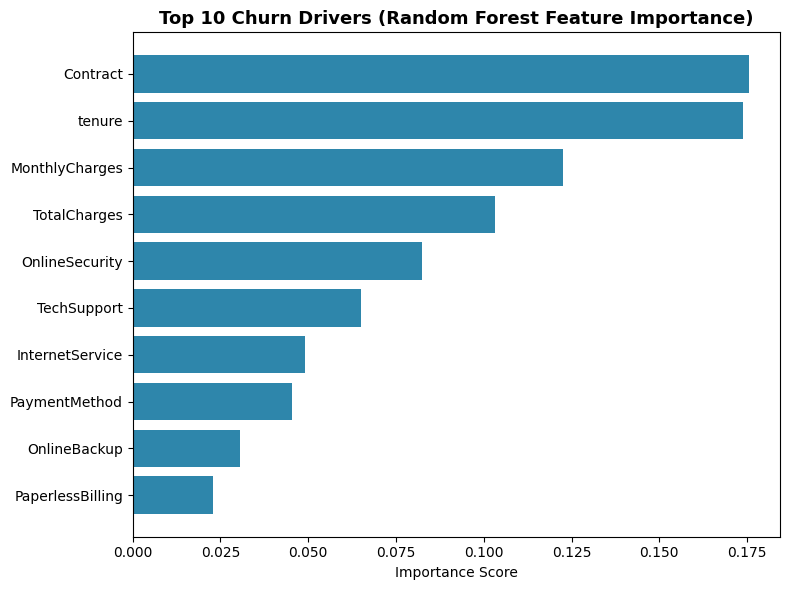

In [18]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.head(10))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))
top10 = importance_df.head(10)
ax.barh(top10['Feature'][::-1], top10['Importance'][::-1], color='#2E86AB')
ax.set_title('Top 10 Churn Drivers (Random Forest Feature Importance)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('C:/Users/Dell/Desktop/churn-customer-diagnosis/reports/06_feature_importance.png', dpi=150)
plt.show()